# Student Performance Analysis

## Overview

This project explores student performance data using Python, Pandas, and Matplotlib.

## Objectives

* Understand the dataset and its features.
* Explore relationships between study time, absences, and grades.
* Visualize patterns in student performance.
* Practice exploratory data analysis (EDA).


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

C:\Users\pardis\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
df = pd.read_csv("F:/MYNazarian/student-performance-analysis/data/student-mat.csv", sep=";")
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [3]:
df.shape

(395, 33)

In [4]:
df.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [6]:
df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

In [7]:
df[["G1", "G2", "G3"]].describe()

,G1,G2,G3
count,395.000000,395.000000,395.000000
mean,10.908861,10.713924,10.415190
std,3.319195,3.761505,4.581443
min,3.000000,0.000000,0.000000
25%,8.000000,9.000000,8.000000
50%,11.000000,11.000000,11.000000
75%,13.000000,13.000000,14.000000
max,19.000000,19.000000,20.000000


In [8]:
df.groupby("studytime")["G3"].mean()

studytime
1    10.047619
2    10.171717
3    11.400000
4    11.259259
Name: G3, dtype: float64

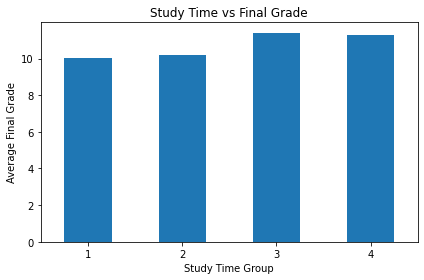

In [9]:
study_grade = df.groupby("studytime")["G3"].mean()

study_grade.plot(
    kind="bar",
    xlabel="Study Time Group",
    ylabel="Average Final Grade",
    title="Study Time vs Final Grade",
    rot=0
)

plt.tight_layout()
plt.show()

In [10]:
df["studytime"].value_counts().sort_index()

studytime
1    105
2    198
3     65
4     27
Name: count, dtype: int64

In [11]:
df.groupby("studytime")["G3"].agg(["count", "mean", "median"])

,count,mean,median
studytime,,,
1,105,10.047619,10.0
2,198,10.171717,11.0
3,65,11.400000,12.0
4,27,11.259259,12.0


In [12]:
df["studytime"].corr(df["G3"])

0.09781968965319632

In [13]:
from scipy.stats import spearmanr

corr, p_value = spearmanr(df["studytime"], df["G3"])

print("Spearman correlation:", corr)
print("P-value:", p_value)

Spearman correlation: 0.10516968678133246
P-value: 0.036673582871214104


## Finding: Study Time and Final Grades

### Objective

Explore the relationship between weekly study time and students' final grades.

### Results

* Students in study-time groups 3 and 4 had higher average final grades than students in groups 1 and 2.
* Pearson correlation: 0.0978.
* Spearman correlation: 0.1052.
* Spearman p-value: 0.0367.

### Interpretation

The data shows a very weak positive association between study time and final grades. The Spearman test is statistically significant at the 5% level, but the observed association is small.

### Limitations

This analysis does not establish causation. Other factors may influence students' grades, and the results should be interpreted in the context of this dataset.


In [14]:
df["absences"].describe()

count    395.000000
mean       5.708861
std        8.003096
min        0.000000
25%        0.000000
50%        4.000000
75%        8.000000
max       75.000000
Name: absences, dtype: float64

In [15]:
df["absences"].value_counts().sort_index()

absences
0     115
1       3
2      65
3       8
4      53
5       5
6      31
7       7
8      22
9       3
10     17
11      3
12     12
13      3
14     12
15      3
16      7
17      1
18      5
19      1
20      4
21      1
22      3
23      1
24      1
25      1
26      1
28      1
30      1
38      1
40      1
54      1
56      1
75      1
Name: count, dtype: int64

In [16]:
df["absences"].corr(df["G3"])

0.034247316150069325

In [17]:
df["absence_group"] = pd.cut(
    df["absences"],
    bins=[-1, 0, 5, float("inf")],
    labels=["0 absences", "1–5 absences", "6+ absences"]
)

df.groupby("absence_group", observed=True)["G3"].agg(
    ["count", "mean", "median"]
)

,count,mean,median
absence_group,,,
0 absences,115,8.443478,10.0
1–5 absences,134,11.649254,11.0
6+ absences,146,10.835616,11.0


In [18]:
from scipy.stats import spearmanr

corr, p_value = spearmanr(df["absences"], df["G3"])

print("Spearman correlation:", corr)
print("P-value:", p_value)

Spearman correlation: 0.017730669122425113
P-value: 0.7253626110680622


## Finding: Absences and Final Grades

### Objective

Explore the relationship between student absences and final grades.

### Results

* Dataset size: 395 students.
* Mean absences: 5.71.
* Pearson correlation: 0.0342.
* Spearman correlation: 0.0177.
* Spearman p-value: 0.7254.

### Interpretation

The Spearman correlation is close to zero and is not statistically significant at the 5% level. This analysis did not find sufficient evidence of a monotonic association between absences and final grades.

### Limitations

These results do not prove that absences have no effect on grades. Other variables and more complex relationships may be relevant. Correlation does not establish causation.


In [19]:
df[["G1", "G2", "G3"]].corr()

,G1,G2,G3
G1,1.000000,0.852118,0.801468
G2,0.852118,1.000000,0.904868
G3,0.801468,0.904868,1.000000


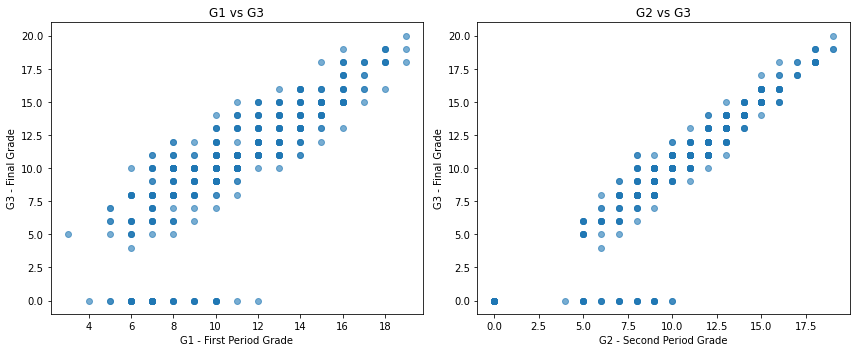

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(df["G1"], df["G3"], alpha=0.6)
axes[0].set_title("G1 vs G3")
axes[0].set_xlabel("G1 - First Period Grade")
axes[0].set_ylabel("G3 - Final Grade")

axes[1].scatter(df["G2"], df["G3"], alpha=0.6)
axes[1].set_title("G2 vs G3")
axes[1].set_xlabel("G2 - Second Period Grade")
axes[1].set_ylabel("G3 - Final Grade")

plt.tight_layout()
plt.show()

## Finding: Previous Grades and Final Grade

### Objective

Explore the relationship between first-period grades (G1), second-period grades (G2), and final grades (G3).

### Results

* G1 and G3 correlation: 0.8015.
* G2 and G3 correlation: 0.9049.
* G2 has a stronger positive correlation with G3 than G1 does.

### Interpretation

Students with higher grades in previous periods generally tended to have higher final grades. The relationship between G2 and G3 was particularly strong.

### Limitations

Correlation does not establish causation. Since G1 and G2 are earlier grades from the same school year, their strong relationships with G3 may partly reflect the way student grades develop over time.


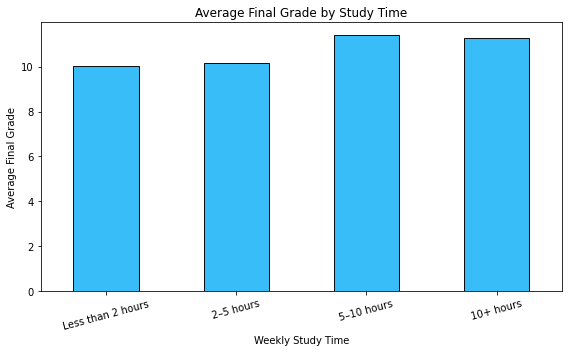

In [21]:

studytime_mean = df.groupby("studytime")["G3"].mean()

studytime_mean.plot(
    kind="bar",
    figsize=(8, 5),
    color="#38BDF8",
    edgecolor="#0B0F14"
)

plt.title("Average Final Grade by Study Time")
plt.xlabel("Weekly Study Time")
plt.ylabel("Average Final Grade")
plt.xticks(
    ticks=range(4),
    labels=[
        "Less than 2 hours",
        "2–5 hours",
        "5–10 hours",
        "10+ hours"
    ],
    rotation=15
)

plt.tight_layout()
plt.show()

### Visualization: Study Time vs Final Grade

The bar chart compares average final grades across four weekly study-time groups.

Students reporting 5–10 hours of weekly study time had the highest average final grade in this dataset. The 10+ hour group had a slightly lower average.

This pattern does not prove that study time causes higher grades. Other factors may influence the results, and the group sizes differ.


## Conclusion

### Key Findings

* Study time showed a very weak positive association with final grades.
* No statistically significant monotonic association was observed between absences and final grades.
* Previous-period grades, especially G2, were strongly correlated with final grades.

### Limitations

* Correlation does not imply causation.
* The findings are based on one dataset of 395 students from Portuguese schools.
* Other factors may influence student performance.

### Next Steps

* Explore additional variables in the dataset.
* Improve visualizations and investigate patterns.
* Learn how to build a simple machine learning model.


In [22]:
X = df[["G1", "G2"]]
y = df["G3"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

X.head()

Features shape: (395, 2)
Target shape: (395,)


,G1,G2
0,5,6
1,5,5
2,7,8
3,15,14
4,6,10


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (316, 2)
X_test: (79, 2)
y_train: (316,)
y_test: (79,)


In [24]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
print("Model training completed!")

Model training completed!


In [25]:
from sklearn.metrics import mean_absolute_error, r2_score
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"MAE: {mae:.2f}")
print(f"R²: {r2:.3f}")

MAE: 1.26
R²: 0.795


In [26]:
results = pd.DataFrame({
    "Actual Grade": y_test,
    "Predicted Grade": y_pred
})

results["Prediction Error"] = (
    results["Actual Grade"] - results["Predicted Grade"]
)
results.head(10).round(2)

,Actual Grade,Predicted Grade,Prediction Error
78,10,7.21,2.79
371,12,12.17,-0.17
248,5,3.42,1.58
55,10,8.21,1.79
390,9,8.37,0.63
223,13,12.83,0.17
42,18,18.94,-0.94
234,6,6.38,-0.38
316,0,7.21,-7.21
116,14,12.67,1.33


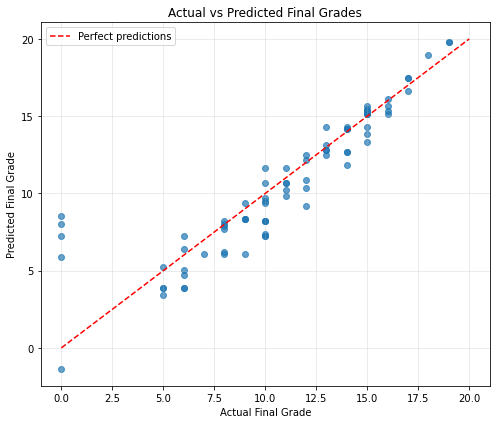

In [27]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([0, 20], [0, 20], "r--", label="Perfect predictions")
plt.xlabel("Actual Final Grade")
plt.ylabel("Predicted Final Grade")
plt.title("Actual vs Predicted Final Grades")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Machine Learning: Predicting Final Grades

### Objective

Build a Linear Regression model to predict students' final grades (G3) using first-period (G1) and second-period (G2) grades.

### Method

* Features: G1 and G2
* Target: G3
* Train-test split: 80% training, 20% testing
* Model: Linear Regression
* Evaluation metrics: Mean Absolute Error (MAE) and R²

### Results

* MAE: 1.26
* R²: 0.795

### Interpretation

The model achieved a Mean Absolute Error of 1.26 grade points on the test set. Its R² score was 0.795, indicating that it explained approximately 79.5% of the variation in final grades in this test set.

### Limitations

* The evaluation uses a single train-test split.
* Results may vary with different data splits or other datasets.
* G1 and G2 are previous-period grades, so this model depends on those grades being available at prediction time.
* These results do not establish that the model will generalize equally well to other schools or student populations.

### Next Steps

* Compare actual and predicted grades.
* Evaluate model performance with cross-validation.
* Explore additional features and compare alternative models.


In [28]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
cv_model = LinearRegression()
scores = cross_val_score(
    cv_model,
    X,
    y,
    cv=5,
    scoring="r2"
)
print("R² scores:", scores.round(3))
print("Mean R²:", round(scores.mean(), 3))
print("Standard deviation:", round(scores.std(), 3))

R² scores: [0.861 0.902 0.832 0.755 0.709]
Mean R²: 0.812
Standard deviation: 0.07


In [29]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
cv_model = LinearRegression()
scores = cross_val_score(
    cv_model,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)
print("R² scores:", scores.round(3))
print("Mean R²:", round(scores.mean(), 3))
print("Standard deviation:", round(scores.std(), 3))

R² scores: [0.818 0.854 0.867 0.801 0.796]
Mean R²: 0.827
Standard deviation: 0.028


### Cross-Validation Results

To evaluate the stability of the Linear Regression model, I performed 5-fold cross-validation on the training set using the R² metric.

**Results:**

* Mean R²: 0.827
* Standard deviation: 0.028
* Fold R² scores: 0.818, 0.854, 0.867, 0.801, 0.796

The model achieved a mean R² of 0.827 across the five validation folds, with relatively low variation between folds.

These results provide an estimate of model performance across different training and validation splits. The test set remains separate for final evaluation.

**Limitations:** The model uses only first-period (G1) and second-period (G2) grades to predict the final grade (G3). Its performance does not necessarily generalize to predictions made before these grades are available.


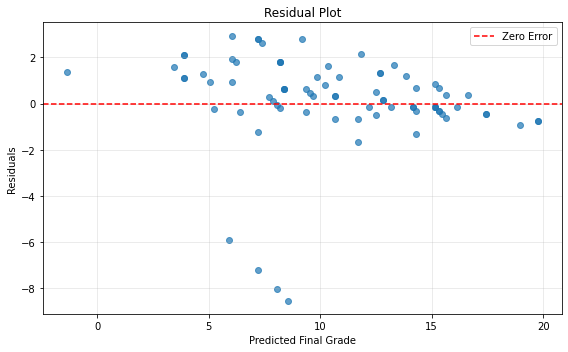

In [30]:
residuals = y_test - y_pred
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(y=0, color="red", linestyle="--", label="Zero Error")
plt.xlabel("Predicted Final Grade")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Residual Analysis

The residual plot shows that most prediction errors are distributed around the zero-error line. However, a few observations have large negative residuals, meaning the model overestimated their final grades.

These observations may represent cases that the model does not capture well using only G1 and G2 as input features.

Further investigation of these observations could help identify potential limitations of the model. The residual plot alone does not establish why these errors occurred.


In [31]:
error_analysis = pd.DataFrame({
    "Actual Grade": y_test,
    "Predicted Grade": y_pred
})
error_analysis["Residual"] = (
    error_analysis["Actual Grade"]
    - error_analysis["Predicted Grade"]
)
error_analysis["Absolute Error"] = (
    error_analysis["Residual"].abs()
)
error_analysis.sort_values(
    by="Absolute Error",
    ascending=False
).head(10).round(2)

,Actual Grade,Predicted Grade,Residual,Absolute Error
334,0,8.53,-8.53,8.53
140,0,8.04,-8.04,8.04
316,0,7.21,-7.21,7.21
168,0,5.89,-5.89,5.89
370,9,6.06,2.94,2.94
33,12,9.20,2.80,2.80
78,10,7.21,2.79,2.79
375,10,7.21,2.79,2.79
157,10,7.38,2.62,2.62
73,14,11.84,2.16,2.16


In [32]:
# Find test samples with an actual final grade of zero
zero_grade_indices = y_test[y_test == 0].index
# Inspect their input features and predictions
zero_grade_analysis = X_test.loc[zero_grade_indices].copy()
zero_grade_analysis["Actual Grade"] = y_test.loc[
    zero_grade_indices
]
zero_grade_analysis["Predicted Grade"] = model.predict(
    X_test.loc[zero_grade_indices]
)
zero_grade_analysis.round(2)

,G1,G2,Actual Grade,Predicted Grade
316,8,8,0,7.21
334,10,9,0,8.53
140,7,9,0,8.04
137,4,0,0,-1.38
168,6,7,0,5.89


In [33]:
error_analysis["Actual Grade"] = error_analysis["Actual Grade"].astype(float)
error_analysis["Grade Group"] = pd.cut(
    error_analysis["Actual Grade"],
    bins=[-1, 5, 10, 15, 20],
    labels=["0–5", "6–10", "11–15", "16–20"]
)
error_analysis.groupby(
    "Grade Group",
    observed=False
).agg(
    Sample_Count=("Residual", "count"),
    MAE=("Absolute Error", "mean"),
    Mean_Residual=("Residual", "mean")
).round(2)

,Sample_Count,MAE,Mean_Residual
Grade Group,,,
0–5,9,3.90,-2.75
6–10,29,1.24,0.92
11–15,31,0.74,0.38
16–20,10,0.58,-0.12


### Error Analysis by Grade Group

I evaluated the model's prediction errors across different ranges of actual final grades.

The model showed the highest Mean Absolute Error (MAE) in the 0–5 grade group (3.90), compared with 1.24 for grades 6–10, 0.74 for grades 11–15, and 0.58 for grades 16–20.

The negative mean residual in the lowest grade group (-2.75) indicates that the model tended to overestimate grades in this group.

These results suggest that the model performs less accurately for students with low final grades. However, the number of observations in each group differs, and this analysis alone does not establish the cause of the errors.

Further work could investigate additional features and compare alternative regression models.


In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score
# Model 1: Previous period grades only
X_train_basic = X_train[["G1", "G2"]]
X_test_basic = X_test[["G1", "G2"]]
# Model 2: Grades + study time + absences
features = ["G1", "G2", "studytime", "absences"]
X_train_extended = df.loc[X_train.index, features]
X_test_extended = df.loc[X_test.index, features]
# Train both models
basic_model = LinearRegression()
basic_model.fit(X_train_basic, y_train)
extended_model = LinearRegression()
extended_model.fit(X_train_extended, y_train)
# Evaluate on the same test set
basic_predictions = basic_model.predict(X_test_basic)
extended_predictions = extended_model.predict(X_test_extended)
# Compare results
comparison = pd.DataFrame({
    "Model": ["Basic Model", "Extended Model"],
    "MAE": [
        mean_absolute_error(y_test, basic_predictions),
        mean_absolute_error(y_test, extended_predictions)
    ],
    "R2": [
        r2_score(y_test, basic_predictions),
        r2_score(y_test, extended_predictions)
    ]
})
comparison.round(3)

,Model,MAE,R2
0,Basic Model,1.262,0.795
1,Extended Model,1.313,0.796


### Comparing Basic and Extended Models

I compared two Linear Regression models using the same training and test split.

The basic model used G1 and G2 as input features, while the extended model also included study time and absences.

**Results:**

| Model          |   MAE |    R² |
| -------------- | ----: | ----: |
| Basic Model    | 1.262 | 0.795 |
| Extended Model | 1.313 | 0.796 |

The extended model achieved a nearly identical R² score but had a slightly higher MAE. Adding study time and absences did not meaningfully improve predictive performance on this test set.

For now, the basic model remains the simpler option with lower MAE. Further experiments using cross-validation and additional features could help determine whether other inputs improve performance.


In [35]:
# Model 3: Add previous failures
features_v3 = ["G1", "G2", "studytime", "absences", "failures"]
X_train_v3 = df.loc[X_train.index, features_v3]
X_test_v3 = df.loc[X_test.index, features_v3]
model_v3 = LinearRegression()
model_v3.fit(X_train_v3, y_train)
predictions_v3 = model_v3.predict(X_test_v3)
comparison_v3 = pd.DataFrame({
    "Model": [
        "Basic Model",
        "Extended Model",
        "Extended + Failures"
    ],
    "MAE": [
        mean_absolute_error(y_test, basic_predictions),
        mean_absolute_error(y_test, extended_predictions),
        mean_absolute_error(y_test, predictions_v3)
    ],
    "R2": [
        r2_score(y_test, basic_predictions),
        r2_score(y_test, extended_predictions),
        r2_score(y_test, predictions_v3)
    ]
})
comparison_v3.round(3)

,Model,MAE,R2
0,Basic Model,1.262,0.795
1,Extended Model,1.313,0.796
2,Extended + Failures,1.339,0.782


### Feature Selection Experiment: Previous Failures

I tested whether adding the `failures` feature improved the Linear Regression model.

The model using G1, G2, study time, absences, and previous failures achieved an MAE of 1.339 and an R² score of 0.782 on the test set.

Compared with the basic model (MAE: 1.262, R²: 0.795), the new model performed worse on both metrics.

This experiment shows that adding more features does not automatically improve predictive performance. The usefulness of each feature should be evaluated rather than assumed.

These results are specific to the current train-test split and should be interpreted with that limitation in mind.


In [36]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
models = {
    "Basic Model": ["G1", "G2"],
    "Extended Model": ["G1", "G2", "studytime", "absences"],
    "Extended + Failures": [
        "G1", "G2", "studytime", "absences", "failures"
    ]
}
cv_results = []
for model_name, features in models.items():
    X_features = df.loc[X_train.index, features]
    scores = cross_val_score(
        LinearRegression(),
        X_features,
        y_train,
        cv=5,
        scoring="r2"
    )
    cv_results.append({
        "Model": model_name,
        "Mean CV R2": scores.mean(),
        "Std CV R2": scores.std()
    })
pd.DataFrame(cv_results).round(3)

,Model,Mean CV R2,Std CV R2
0,Basic Model,0.827,0.028
1,Extended Model,0.829,0.029
2,Extended + Failures,0.833,0.027


### Comparing Models with Cross-Validation

I compared three Linear Regression models using 5-fold cross-validation on the training set.

| Model               | Mean CV R² | Standard Deviation |
| ------------------- | ---------: | -----------------: |
| Basic Model         |      0.827 |              0.028 |
| Extended Model      |      0.829 |              0.029 |
| Extended + Failures |      0.833 |              0.027 |

The model including previous failures achieved the highest mean cross-validation R² (0.833). However, the improvement over the basic model was small.

The test-set evaluation showed a different result: the model with additional features performed worse than the basic model on both MAE and R². This highlights why model selection should consider both cross-validation and final test-set performance.

For now, the basic model remains a reasonable choice because it is simpler and achieved a lower test-set MAE. Further validation would be needed before concluding that the additional features improve generalization.


In [37]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
# Use the same features for both models
features = ["G1", "G2"]
X_train_basic = X_train[features]
X_test_basic = X_test[features]
# Model 1: Linear Regression
linear_model = LinearRegression()
linear_model.fit(X_train_basic, y_train)
linear_predictions = linear_model.predict(X_test_basic)
# Model 2: Random Forest
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    min_samples_leaf=2
)
rf_model.fit(X_train_basic, y_train)
rf_predictions = rf_model.predict(X_test_basic)
# Compare both models on the same test set
comparison_rf = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [
        mean_absolute_error(y_test, linear_predictions),
        mean_absolute_error(y_test, rf_predictions)
    ],
    "R2": [
        r2_score(y_test, linear_predictions),
        r2_score(y_test, rf_predictions)
    ]
})
comparison_rf.round(3)

,Model,MAE,R2
0,Linear Regression,1.262,0.795
1,Random Forest,1.360,0.772


### Comparing Linear Regression and Random Forest

I compared Linear Regression and Random Forest using the same input features (G1 and G2) and the same train-test split.

| Model             |   MAE |    R² |
| ----------------- | ----: | ----: |
| Linear Regression | 1.262 | 0.795 |
| Random Forest     | 1.360 | 0.772 |

Linear Regression achieved a lower MAE and a higher R² score than Random Forest on the test set.

This experiment shows that a more complex model does not necessarily produce better predictions. Based on these results, Linear Regression remains the preferred baseline for this experiment.

Further validation would be needed before concluding that it generalizes better to unseen data.


In [38]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
X_train_compare = X_train[["G1", "G2"]]
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        min_samples_leaf=2
    )
}
cv_results = []
for name, estimator in models.items():
    scores = cross_val_score(
        estimator,
        X_train_compare,
        y_train,
        cv=5,
        scoring="r2"
    )
    cv_results.append({
        "Model": name,
        "Mean CV R2": scores.mean(),
        "Std CV R2": scores.std()
    })
pd.DataFrame(cv_results).round(3)

,Model,Mean CV R2,Std CV R2
0,Linear Regression,0.827,0.028
1,Random Forest,0.793,0.037


### Model Comparison

I compared Linear Regression and Random Forest using the same input features (`G1` and `G2`) and a consistent train-test split.

Linear Regression achieved a mean cross-validation R² of **0.827**, compared with **0.793** for Random Forest. On the held-out test set, Linear Regression also achieved a lower MAE (**1.262 vs. 1.360**) and a slightly higher R² (**0.795 vs. 0.772**).

These results suggest that Linear Regression is a more suitable baseline for this experiment. However, the conclusion is limited to this dataset, feature set, and evaluation setup.
